# Filling numerical data -> Imputer(Univariate)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
data = pd.read_csv('../../datasets/titanic_toy.csv')

In [4]:
data.head(5)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
data.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [8]:
data.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [9]:
# Splitting data
x = data.drop(columns=['Survived'])
y = data['Survived']

In [10]:
x.head(5)

,Age,Fare,Family
0,22.0,7.2500,1
1,38.0,71.2833,1
2,26.0,7.9250,0
3,35.0,53.1000,1
4,35.0,8.0500,0


In [11]:
y.head(5)

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)


In [13]:
x_train.shape

(623, 3)

In [14]:
x_test.shape

(268, 3)

In [15]:
x_train.isnull().mean()*100

Age       19.903692
Fare       4.815409
Family     0.000000
dtype: float64

In [16]:
# determining the mean and median of the Age and fare column
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

# mean and median of the fare column


mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [18]:
mean_age,median_age

(np.float64(29.256352705410823), np.float64(28.0))

In [19]:
mean_fare,median_fare

(np.float64(31.79834806070826), np.float64(14.4542))

In [21]:
x_train['mean_age'] = x_train['Age'].fillna(mean_age)
x_train['median_age'] = x_train['Age'].fillna(median_age)
x_train['mean_fare'] = x_train['Fare'].fillna(mean_fare)
x_train['median_fare'] = x_train['Fare'].fillna(median_fare)

In [22]:
x_train.head(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
445,4.0,81.8583,2,4.000000,4.0,81.8583,81.8583
650,NaN,7.8958,0,29.256353,28.0,7.8958,7.8958
172,1.0,11.1333,2,1.000000,1.0,11.1333,11.1333
450,36.0,27.7500,3,36.000000,36.0,27.7500,27.7500
314,43.0,26.2500,2,43.000000,43.0,26.2500,26.2500


In [23]:
x_train.isnull().mean()*100

Age            19.903692
Fare            4.815409
Family          0.000000
mean_age        0.000000
median_age      0.000000
mean_fare       0.000000
median_fare     0.000000
dtype: float64

In [26]:
# determing the variance of the data after filling with missing value using mean and median in age and fare column
print('The orifinal variance of Age column is : ',x_train['Age'].var())
print('The variance of age column after filling missing value using mean ',x_train['mean_age'].var())
print('The variance of age column after filling missing value using mean ',x_train['median_age'].var())
# printing the variance of the fare column
print('The variance of the age column after filling missing value with mean values is : ',x_train['Fare'].var())
print('The variance of the age column after filling missing value with median values is : ',x_train['mean_fare'].var())
print('The variance of the age column after filling missing value with median values is : ',x_train['median_fare'].var())

The orifinal variance of Age column is :  211.9518806464334
The variance of age column after filling missing value using mean  169.69780797736954
The variance of age column after filling missing value using mean  169.94984651902163
The variance of the age column after filling missing value with mean values is :  2666.9296723129737
The variance of the age column after filling missing value with median values is :  2538.2996238091323
The variance of the age column after filling missing value with median values is :  2552.1099348908238


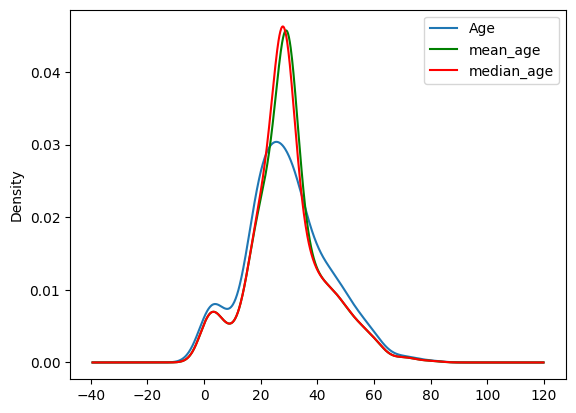

In [29]:
# drawing KDE plot
fig =  plt.figure()
ax = fig.add_subplot(111)

# original variable disribution
x_train['Age'].plot(kind='kde',ax=ax)

# mean_age plot
x_train['mean_age'].plot(kind='kde',ax=ax,color='green')

# median_age plot
x_train['median_age'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

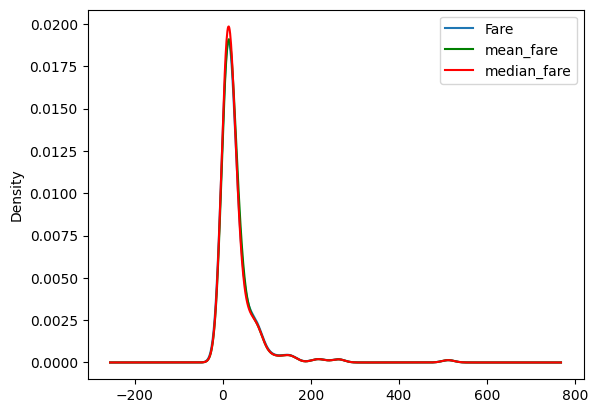

In [30]:
# drawing KDE plot
fig =  plt.figure()
ax = fig.add_subplot(111)

# original variable disribution
x_train['Fare'].plot(kind='kde',ax=ax)

# mean_age plot
x_train['mean_fare'].plot(kind='kde',ax=ax,color='green')

# median_age plot
x_train['median_fare'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [33]:
# determing the covariance of each column -> What is the relationship between one column to another columns
x_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,211.951881,71.822073,-6.932603,211.951881,211.951881,67.757268,65.775061
Fare,71.822073,2666.929672,18.612474,56.998513,59.765747,2666.929672,2666.929672
Family,-6.932603,18.612474,2.997027,-5.550541,-5.533529,17.714766,17.767537
mean_age,211.951881,56.998513,-5.550541,169.697808,169.697808,54.249388,52.662348
median_age,211.951881,59.765747,-5.533529,169.697808,169.949847,56.883154,55.227061
mean_fare,67.757268,2666.929672,17.714766,54.249388,56.883154,2538.299624,2538.299624
median_fare,65.775061,2666.929672,17.767537,52.662348,55.227061,2538.299624,2552.109935


In [34]:
x_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.088197,-0.310167,1.000000,1.000000,0.085804,0.083017
Fare,0.088197,1.000000,0.205140,0.084564,0.088616,1.000000,1.000000
Family,-0.310167,0.205140,1.000000,-0.246123,-0.245186,0.203104,0.203157
mean_age,1.000000,0.084564,-0.246123,1.000000,0.999258,0.082658,0.080023
median_age,1.000000,0.088616,-0.245186,0.999258,1.000000,0.086607,0.083857
mean_fare,0.085804,1.000000,0.203104,0.082658,0.086607,1.000000,0.997291
median_fare,0.083017,1.000000,0.203157,0.080023,0.083857,0.997291,1.000000


<Axes: >

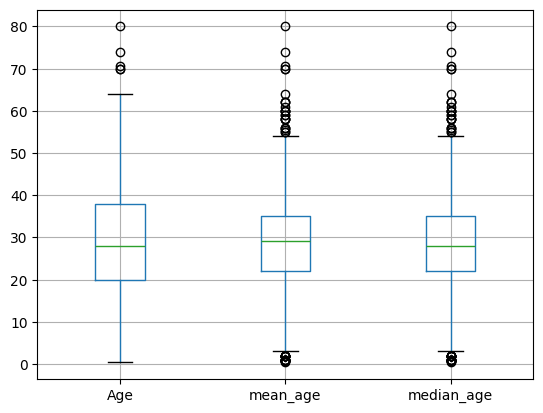

In [36]:
# drawing box-cox plot
x_train[['Age','mean_age','median_age']].boxplot()

<Axes: >

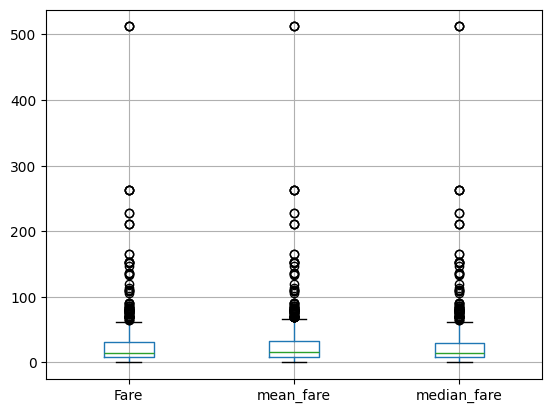

In [37]:
x_train[['Fare','mean_fare','median_fare']].boxplot()

In [42]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [44]:
# applying pipeline over data 
trf  = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [45]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [47]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [48]:
trf.named_transformers_['imputer2'].statistics_

array([31.79834806])

In [49]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [50]:
x_train

array([[  4.        ,  81.8583    ,   2.        ],
       [ 28.        ,   7.8958    ,   0.        ],
       [  1.        ,  11.1333    ,   2.        ],
       ...,
       [ 41.        ,  31.79834806,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]], shape=(623, 3))

In [51]:
x_test

array([[ 28.        ,  15.2458    ,   2.        ],
       [ 31.        ,  10.5       ,   0.        ],
       [ 20.        ,   7.925     ,   0.        ],
       [  6.        ,  33.        ,   1.        ],
       [ 14.        ,  11.2417    ,   1.        ],
       [ 26.        ,  78.85      ,   0.        ],
       [ 28.        ,   7.75      ,   0.        ],
       [ 16.        ,  18.        ,   2.        ],
       [ 16.        ,   7.75      ,   0.        ],
       [ 19.        ,  26.2833    ,   2.        ],
       [ 37.        ,  53.1       ,   1.        ],
       [ 44.        ,   8.05      ,   0.        ],
       [ 28.        ,  25.4667    ,   4.        ],
       [ 30.        ,   7.225     ,   0.        ],
       [ 36.        ,  13.        ,   0.        ],
       [ 16.        ,  39.4       ,   1.        ],
       [ 42.        ,  52.5542    ,   1.        ],
       [ 28.        ,   7.8292    ,   0.        ],
       [ 27.        ,  13.        ,   0.        ],
       [ 47.        ,  52.     